CSCI580 Final Project Group 9

Imports
Source:
- Final Project Slides and: project requires PyTorch, MNIST, custom PNG data,
  accuracy statistics, F1-score, and confusion matrix.
- PerfEval slides: model performance metrics.

In [12]:
import os
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Reproducibility + Device Setup
Source:
- General PyTorch setup.

Training samples: 48000
Validation samples: 12000
MNIST test samples: 10000
Custom digit samples: 290
MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total parameters: 235146
Trainable parameters: 235146
Epoch [1/3] Train Loss: 0.4936, Train Acc: 0.8456, Val Loss: 0.2311, Val Acc: 0.9308
Epoch [2/3] Train Loss: 0.2649, Train Acc: 0.9192, Val Loss: 0.1803, Val Acc: 0.9453
Epoch [3/3] Train Loss: 0.2175, Train Acc: 0.9343, Val Loss: 0.1541, Val Acc: 0.9544


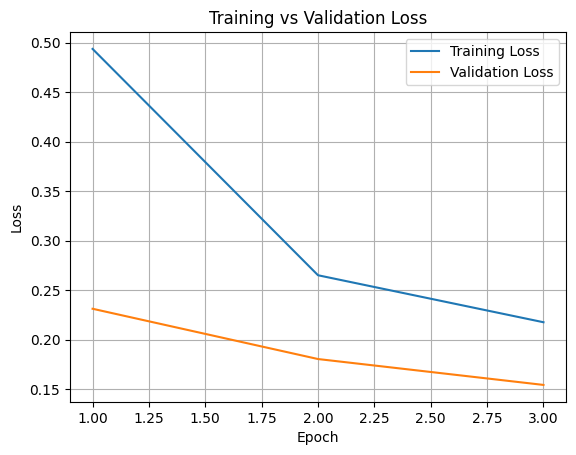

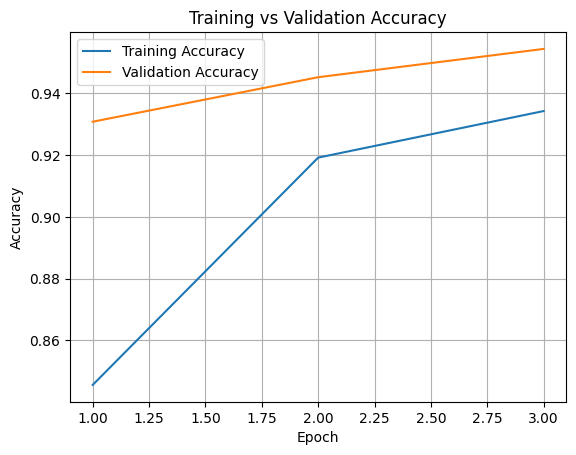

MNIST Test Data
Accuracy: 0.9574
Error Rate: 0.04259999999999997

F1 Score Per Digit:
Digit 0: 0.9675
Digit 1: 0.9786
Digit 2: 0.9577
Digit 3: 0.9592
Digit 4: 0.9551
Digit 5: 0.9536
Digit 6: 0.9589
Digit 7: 0.9559
Digit 8: 0.9426
Digit 9: 0.9409

Confusion Matrix:
[[ 968    0    1    0    0    0    7    1    3    0]
 [   0 1118    2    3    0    0    3    0    9    0]
 [  12    1  985    2    4    0   12    8    8    0]
 [   1    1   17  964    0    9    0    9    8    1]
 [   1    2    2    0  937    0   17    2    9   12]
 [  13    1    0   14    2  833   13    1   12    3]
 [  10    3    0    1    2    3  934    0    5    0]
 [   2   15   15    1    4    0    0  976   10    5]
 [   8    1    3    6    4    2    2    4  944    0]
 [   6    8    0    9   27    8    2   13   21  915]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.97      0.99      0.98      1135
           2     

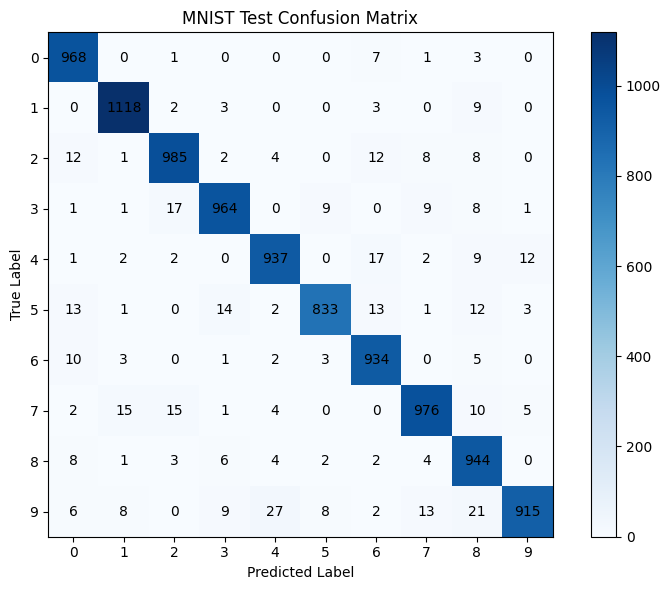

Saved model as final_mlp_digit_classifier.pth


In [13]:
# Locking seed to group number for consistent data
seed = 9

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

"""
Image Transform / Preprocessing
Source:
- Final Project slides, Task 3:
  ToTensor() maps [0,255] -> [0,1]
  Normalize(mean=0.5, std=0.5) maps [0,1] -> [-1,1]
"""

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

"""
Load MNIST Dataset
Source:
- Final Project slides, page 8:
  trainset = datasets.MNIST(... train=True)
  testset = datasets.MNIST(... train=False)
"""

mnist_train_full = datasets.MNIST(
    root="./MNIST_data",
    train=True,
    download=True,
    transform=transform
)

mnist_test = datasets.MNIST(
    root="./MNIST_data",
    train=False,
    download=True,
    transform=transform
)

"""
Training / Validation Split
Source:
- Model Tuning slides, slide "Training, Validation and Test"
- Model Tuning slides, slide "Training with Validation"
"""

train_size = int(0.8 * len(mnist_train_full))
val_size = len(mnist_train_full) - train_size

mnist_train, mnist_val = random_split(
    mnist_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

batch_size = 64

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

print("Training samples:", len(mnist_train))
print("Validation samples:", len(mnist_val))
print("MNIST test samples:", len(mnist_test))

"""
Custom Project Dataset Loader
Source:
- Final Project slides, Task 1:
  filename format: <label/digit>-<groupID>-<memberID>.png
- Final Project slides, Task 2:
  read PNG files and assign labels
- Final Project slides, Task 3:
  preprocess images using PyTorch transforms
"""

class ProjectDigitDataset(Dataset):
    def __init__(self, folder_path):
        self.folder_path = folder_path

        self.files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".png")
        ]

        self.files.sort()

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((28, 28)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        # Expected filename:
        # <label/digit>-<groupID>-<memberID>.png
        # Example:
        # 3-4-1.png means digit 3, group 4, member 1

        name_without_extension = filename.replace(".png", "")
        parts = name_without_extension.split("-")

        label = int(parts[0])
        group_id = int(parts[1])
        member_id = int(parts[2])

        image_path = os.path.join(self.folder_path, filename)

        image = Image.open(image_path)
        image = self.transform(image)

        return image, label, group_id, member_id, filename


# Change this path if your custom digit folder is elsewhere
custom_digits_folder = "./digits"

if os.path.exists(custom_digits_folder):
    custom_dataset = ProjectDigitDataset(custom_digits_folder)
    custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=False)
    print("Custom digit samples:", len(custom_dataset))
else:
    custom_dataset = None
    custom_loader = None
    print("No custom digits folder found yet.")

"""
MLP Model Definition
Source:
- Final Project slides:
  Must use MLP / fully connected feedforward neural network only.
- BuildTrainNN slides:
  Example architecture uses input 784, hidden layers, output 10.
- Model Tuning slides:
  Architecture hyperparameters include number of layers,
  neurons per layer, activation function, and dropout.
"""

class MLP(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        # Flatten 28x28 image into 784 input features.
        x = x.view(x.shape[0], -1)
        return self.network(x)


model = MLP(dropout_rate=0.3).to(device)

print(model)

"""
Count Parameters
Source:
- Final Report requirements:
  include number of neurons, layers, weights, and key hyperparameters.
"""

def count_parameters(model):
    total = 0
    trainable = 0

    for param in model.parameters():
        num = param.numel()
        total += num

        if param.requires_grad:
            trainable += num

    return total, trainable


total_params, trainable_params = count_parameters(model)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

"""
Loss Function and Optimizer
Source:
- BuildTrainNN slides:
  discusses NLLLoss, CrossEntropyLoss, SGD, Adam.
- PerfEval slides:
  CrossEntropyLoss / log loss is used during training.
- Model Tuning slides:
  optimizer type, learning rate, and weight decay are hyperparameters.
"""

criterion = nn.CrossEntropyLoss()

learning_rate = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

"""
Training Function
Source:
- BuildTrainNN slides, training main loop:
  optimizer.zero_grad()
  output = model(input)
  loss = loss_fn(output, target)
  loss.backward()
  optimizer.step()
"""

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

"""
Validation Function
Source:
- Model Tuning slides, slide "Training with Validation":
  validation phase after each epoch,
  model.eval(),
  disable gradient computation,
  forward pass only,
  compute validation loss and metrics.
"""

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

"""
Train Model Across Epochs
Source:
- Model Tuning slides:
  track training and validation loss.
- Final Project slides:
  validate while training and tune hyperparameters.
"""

epochs = 3
#epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_model_path = "best_mlp_model.pth"

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )


model.load_state_dict(torch.load(best_model_path, map_location=device))

"""
Plot Training vs Validation Loss
Source:
- Model Tuning slides:
  overfitting slides show training vs validation loss.
- Final Project slides:
  report requires training vs validation loss over iterations.
"""

plt.figure()
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


plt.figure()
plt.plot(range(1, epochs + 1), train_accuracies, label="Training Accuracy")
plt.plot(range(1, epochs + 1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

"""
General Evaluation Function for MNIST Test Data
Source:
- Final Project slides:
  test on MNIST test images.
- PerfEval slides:
  accuracy, error rate, F1-score, and confusion matrix.
"""

def evaluate_mnist_test_data(model, dataloader, device, dataset_name="MNIST Test Data"):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    error_rate = 1 - accuracy

    f1_per_digit = f1_score(
        all_labels,
        all_predictions,
        average=None,
        labels=list(range(10)),
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=list(range(10))
    )

    print(dataset_name)
    print("Accuracy:", accuracy)
    print("Error Rate:", error_rate)

    print("\nF1 Score Per Digit:")
    for digit, score in enumerate(f1_per_digit):
        print(f"Digit {digit}: {score:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_predictions,
            labels=list(range(10)),
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "error_rate": error_rate,
        "f1_per_digit": f1_per_digit,
        "confusion_matrix": cm,
        "labels": all_labels,
        "predictions": all_predictions
    }

"""
Custom Image Evaluation Per Group
Source:
- Final Project slides:
  custom filename format:
  <label/digit>-<groupID>-<memberID>.png
- Final Project slides:
  final evaluation should include each group's images.
- PerfEval slides:
  accuracy, error rate, F1-score, confusion matrix.
"""

def evaluate_custom_images_by_group(model, dataloader, device):
    model.eval()

    group_results = defaultdict(lambda: {
        "labels": [],
        "predictions": [],
        "filenames": []
    })

    with torch.no_grad():
        for images, labels, group_ids, member_ids, filenames in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            labels_np = labels.cpu().numpy()
            predictions_np = predictions.cpu().numpy()
            group_ids_np = group_ids.numpy()

            for label, pred, group_id, filename in zip(
                labels_np,
                predictions_np,
                group_ids_np,
                filenames
            ):
                group_id = int(group_id)

                group_results[group_id]["labels"].append(int(label))
                group_results[group_id]["predictions"].append(int(pred))
                group_results[group_id]["filenames"].append(filename)

    print("Group Collected Digit Images - Per Group")

    final_results = {}

    for group_id in sorted(group_results.keys()):
        labels = group_results[group_id]["labels"]
        predictions = group_results[group_id]["predictions"]

        accuracy = accuracy_score(labels, predictions)
        error_rate = 1 - accuracy

        macro_f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )

        cm = confusion_matrix(
            labels,
            predictions,
            labels=list(range(10))
        )

        print(f"\nGroup {group_id}")
        print("------------------------------")
        print("Number of images:", len(labels))
        print("Accuracy:", accuracy)
        print("Error Rate:", error_rate)
        print("Macro F1 Score:", macro_f1)

        final_results[group_id] = {
            "accuracy": accuracy,
            "error_rate": error_rate,
            "macro_f1": macro_f1,
            "confusion_matrix": cm,
            "labels": labels,
            "predictions": predictions,
            "filenames": group_results[group_id]["filenames"]
        }

    return final_results

"""
Evaluate on MNIST Test Data
Source:
- Final Project slides:
  test handwritten digit recognition using MNIST test data.
"""

mnist_results = evaluate_mnist_test_data(
    model,
    test_loader,
    device,
    dataset_name="MNIST Test Data"
)

"""
Evaluate on Group-Collected Custom Images
Source:
- Final Project slides:
  test handwritten digit recognition using all group-collected images.
  Accuracy evaluation should be per FinalProjectGroup.
"""

if custom_loader is not None:
    custom_group_results = evaluate_custom_images_by_group(
        model,
        custom_loader,
        device
    )
else:
    custom_group_results = None
    print("Skipping custom image evaluation because ./digits was not found.")

"""
Plot Confusion Matrix
Source:
- PerfEval slides:
  confusion matrix summarizes classification performance.
- Matplotlib documentation:
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
- Geeksforgeeks:
  https://www.geeksforgeeks.org/python/matplotlib-pyplot-imshow-in-python/
"""

def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.colorbar()

    tick_marks = np.arange(10)
    plt.xticks(tick_marks, range(10))
    plt.yticks(tick_marks, range(10))

    for i in range(10):
        for j in range(10):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(
    mnist_results["confusion_matrix"],
    title="MNIST Test Confusion Matrix"
)

"""
Save Final Model
Source:
- Final Project slides:
  GitHub submission should include experiment materials,
  results, and trained model.
"""

torch.save(model.state_dict(), "final_mlp_digit_classifier.pth")
print("Saved model as final_mlp_digit_classifier.pth")